# 호텔 예약 취소에 대한 데이터 기반 분석 및 보고

자료 준비(shift + enter)

In [31]:
import csv
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

origin_df = None
df = None

def ininialize():
    data_filename = 'hotel_data_modified.csv'

    font_path = 'NanumGothic.ttf'
    fm.fontManager.addfont(font_path)

    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False

    raw_data = None

    with open(f'./{data_filename}', 'r', encoding='utf-8') as file_handle:
        reader = csv.reader(file_handle)
        raw_data = list(reader)

    origin_df = pd.DataFrame(data=raw_data[1:], columns=raw_data[0])
    convert_str_to_int(origin_df, 'lead_time')
    convert_str_to_int(origin_df, 'is_canceled')
    origin_df['reservation_status_date'] = origin_df['reservation_status_date'].astype('datetime64[ns]')
    convert_str_to_int(origin_df, 'adults')
    convert_str_to_int(origin_df, 'children')
    convert_str_to_int(origin_df, 'babies')
    convert_str_to_int(origin_df, 'stays_in_weekend_nights')
    convert_str_to_int(origin_df, 'stays_in_week_nights')
    df = origin_df.copy()

    return origin_df, df

def convert_str_to_int(df, column_name: str):
    # 숫자가 아닌 값은 NaN(빈 값)으로 변환 ('coerce' 옵션)
    df[column_name] = pd.to_numeric(df[column_name], errors='coerce')
    # NaN 값을 0으로 채워줌 (아이 0명으로 가정)
    df[column_name] = df[column_name].fillna(0)
    # 정수형으로 변환
    df[column_name] = df[column_name].astype(int)

origin_df, df = ininialize()

## 호텔 예약 취소에 따른 실제 수요 현황
전체 예약에서 예약 취소가 차지하는 비중을 살펴봅니다.

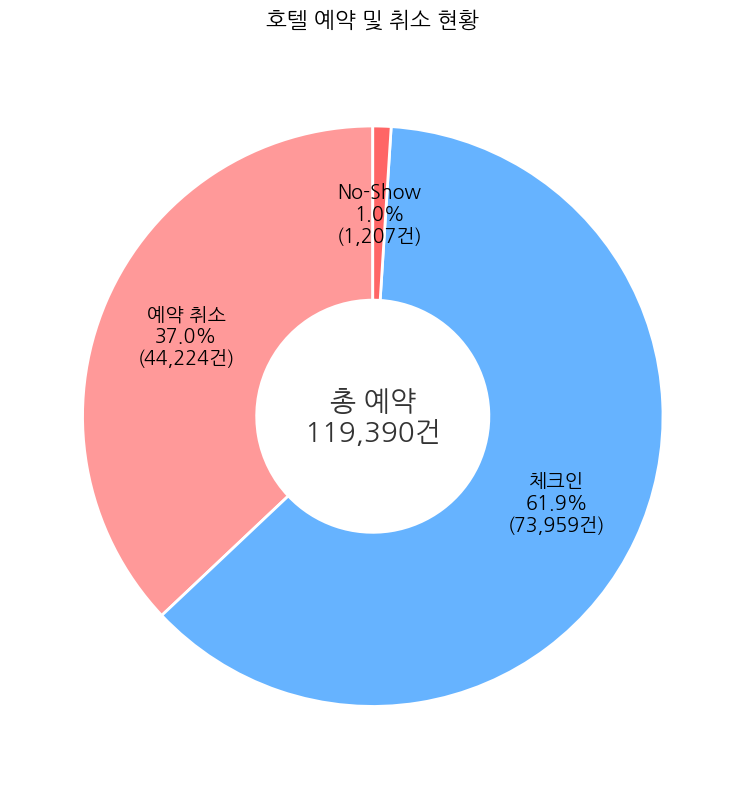

In [32]:
def analyze_realized_demand_after_cancellations():
    total_booking_count = len(df)
    cancel_booking_count = len(df[df['is_canceled'] == 1])
    checkin_count = len(df[df['is_canceled'] == 0])
    no_show_count = len(df[df['reservation_status'] == 'No-Show'])
    checkin_count -= no_show_count

    labels = ['예약 취소', '체크인', 'No-Show']
    sizes = [cancel_booking_count, checkin_count, no_show_count]
    colors = ['#ff9999', '#66b3ff', '#ff6666']

    def make_autopct(pct, all_vals):
        absolute = int(round(pct/100.*sum(all_vals)))
        return f"{pct:.1f}%\n({absolute:,}건)"

    fig, ax = plt.subplots(figsize=(8, 8))

    wedges, texts, autotexts = ax.pie(sizes,
                                  labels=None,
                                  autopct=lambda pct: make_autopct(pct, sizes),
                                  startangle=90,
                                  colors=colors,
                                  pctdistance=0.70,  # 텍스트를 도넛 조각의 정중앙(0.7)에 배치
                                  wedgeprops={'width': 0.6, 'edgecolor': 'w', 'linewidth': 2})

    for i, autotext in enumerate(autotexts):
        current_text = autotext.get_text()
        new_text = f"{labels[i]}\n{current_text}"

        autotext.set_text(new_text)
        autotext.set_color('black')
        autotext.set_fontsize(14)
        autotext.set_fontweight('bold')

    ax.text(0, 0,
        f"총 예약\n{total_booking_count:,}건",
        ha='center', va='center', fontsize=20, fontweight='bold', color='#333333')

    plt.title("호텔 예약 및 취소 현황", fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

analyze_realized_demand_after_cancellations()

위 그래프에서 확인되는 것처럼, 예약 취소 비율은 37%를 차지하고 있어  
실제 체크인이 이루어지는 고객이 예약된 10명중 6명 남짓 된다는 결론을 얻을 수 있습니다.  
추가로 No-Show에 해당하는 취소는 전체 1% 정도라 예약 취소 대비 작은 비중을 차지합니다.

## 예약 취소 요인 분석  
데이터를 기반하여 예약 취소와 다른 요소들 간의 연관 관계를 분석합니다.

### 1. 인원 수에 따른 예약 취소율 분석

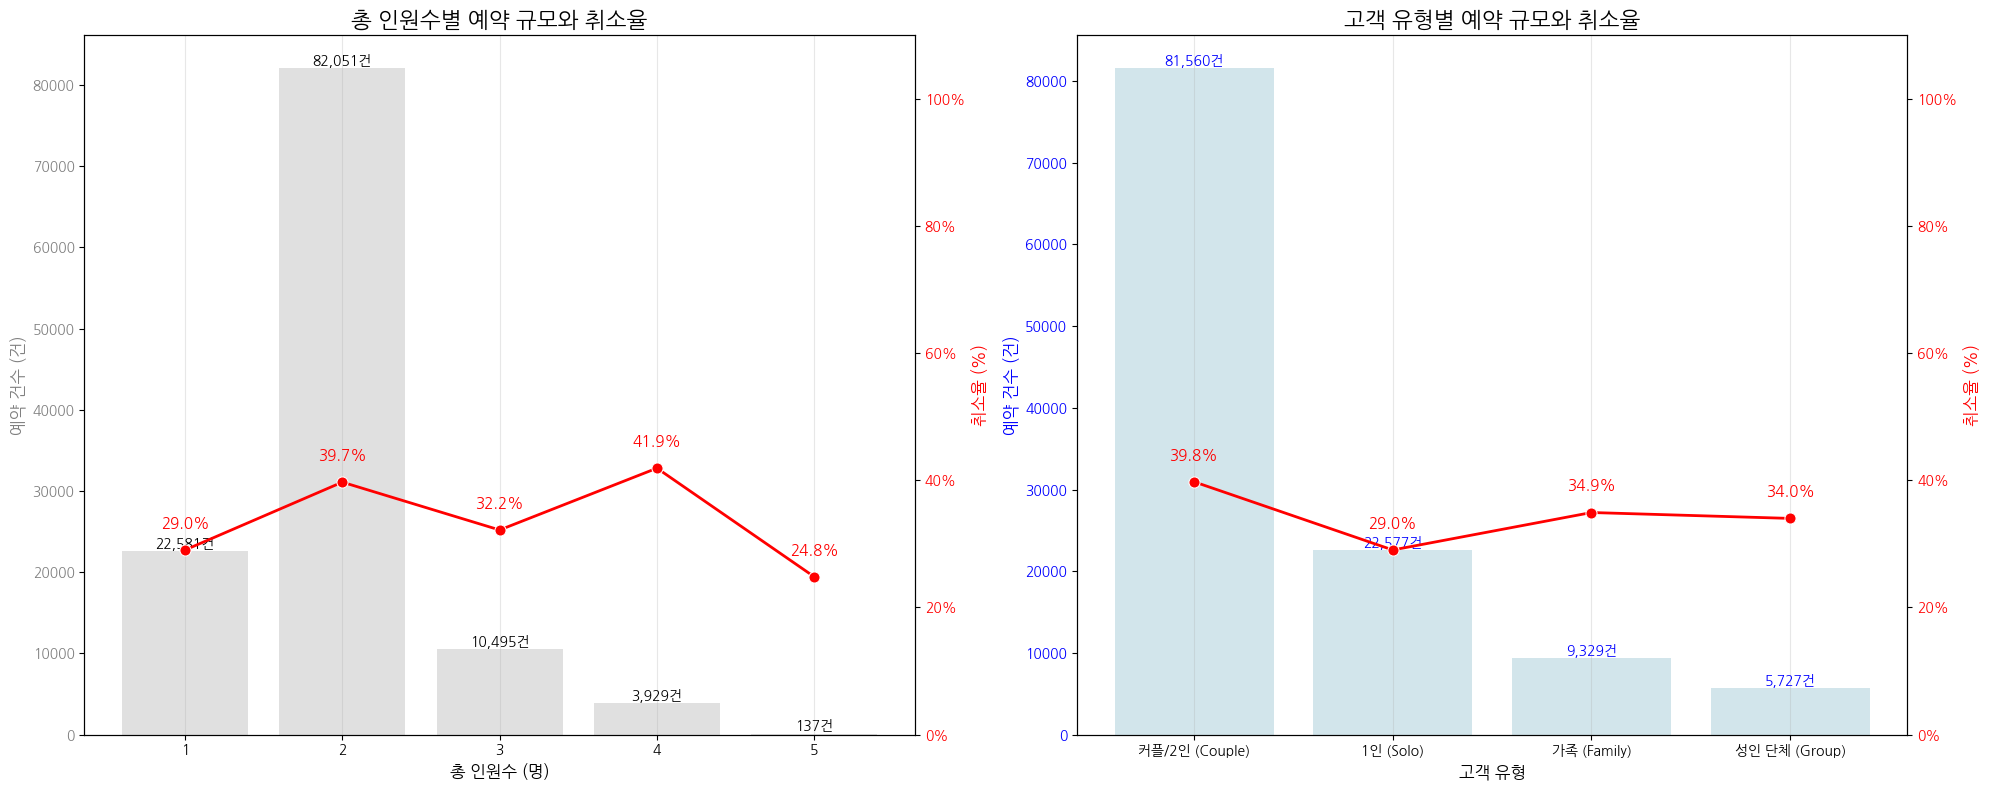

In [44]:
def preprocess_people_data(df):
    people_df = df.copy()

    # 총 인원수 컬럼 생성 (Total People)
    people_df['total_people'] = people_df['adults'] + people_df['children'] + people_df['babies']
    people_df['total_people'] = people_df['total_people'].astype(int)

    # 총 인원이 0명인 데이터는 이상치로 간주하여 제거
    people_df = people_df[people_df['total_people'] > 0]

    # 인원수가 6 명 이상일 경우 일괄 필터링
    people_df = people_df[people_df['total_people'] < 6]

    # 고객 유형(Customer Type) 정의
    def get_customer_type(row):
        # 아이나 아기가 1명이라도 있으면 '가족(Family)'
        if row['children'] > 0 or row['babies'] > 0:
            return '가족 (Family)'
        # 성인이 1명이면 '1인 (Solo)'
        elif row['adults'] == 1:
            return '1인 (Solo)'
        # 성인이 2명이면 '커플/2인 (Couple)'
        elif row['adults'] == 2:
            return '커플/2인 (Couple)'
        # 성인이 3명 이상이면 '단체 (Group)'
        else:
            return '성인 단체 (Group)'

    people_df['customer_type'] = people_df.apply(get_customer_type, axis=1)

    return people_df

people_df = preprocess_people_data(df)

def visualize_people_cancellation(df):
    # 캔버스 설정 (1행 2열)
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # ----------
    # 총 인원수별 예약 규모와 취소율 그래프
    ax1 = axes[0]

    stats1 = df.groupby('total_people')['is_canceled'].agg(['count', 'mean']).reset_index()
    stats1.columns = ['total_people', 'booking_count', 'cancellation_rate']

    # 숫자를 문자열로 변환하여 x축 좌표계를 통일시킨다. 이게 없으면 그래프가 서로 밀려서 그려짐
    stats1['total_people'] = stats1['total_people'].astype(str)

    # 왼쪽 축 예약 건수 막대 그래프
    sns.barplot(data=stats1, x='total_people', y='booking_count',
                color='lightgray', alpha=0.7, ax=ax1, zorder=1)

    ax1.set_ylabel('예약 건수 (건)', fontsize=12, color='gray')
    ax1.set_xlabel('총 인원수 (명)', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='gray')

    # 막대 위 건수 표시
    for p in ax1.patches:
        height = p.get_height()
        ax1.text(p.get_x() + p.get_width()/2., height + 10,
                 f'{int(height):,}건', ha="center", va="bottom", color='black', fontsize=10)

    # 오른쪽 축 취소율 선 그래프
    ax2 = ax1.twinx()
    sns.lineplot(data=stats1, x='total_people', y='cancellation_rate',
                 color='red', marker='o', markersize=8, linewidth=2, ax=ax2, zorder=2)

    ax2.set_ylabel('취소율 (%)', fontsize=12, color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax2.set_ylim(0, 1.1) # 0~110% 범위

    # 선 그래프 포인트 위 % 표시
    for i, rate in enumerate(stats1['cancellation_rate']):
        ax2.text(i, rate + 0.03, f'{rate:.1%}',
                 ha="center", va="bottom", color='red', fontweight='bold', fontsize=11)

    ax1.set_title("총 인원수별 예약 규모와 취소율", fontsize=16)
    ax1.grid(axis='x', alpha=0.3)

    # ----------
    # 고객 유형별 예약 규모와 취소율 그래프
    ax3 = axes[1]

    stats2 = df.groupby('customer_type')['is_canceled'].agg(['count', 'mean']).reset_index()
    stats2.columns = ['customer_type', 'booking_count', 'cancellation_rate']

    stats2 = stats2.sort_values('booking_count', ascending=False)

    # 왼쪽 축 예약 건수 막대 그래프
    sns.barplot(data=stats2, x='customer_type', y='booking_count',
                color='lightblue', alpha=0.6, ax=ax3, zorder=1)

    ax3.set_ylabel('예약 건수 (건)', fontsize=12, color='blue')
    ax3.set_xlabel('고객 유형', fontsize=12)
    ax3.tick_params(axis='y', labelcolor='blue')

    # 막대 위 건수 표시
    for p in ax3.patches:
        height = p.get_height()
        ax3.text(p.get_x() + p.get_width()/2., height + 10,
                 f'{int(height):,}건', ha="center", va="bottom", color='blue', fontsize=10)

    # 오른쪽 축 취소율 선 그래프
    ax4 = ax3.twinx()
    sns.lineplot(data=stats2, x='customer_type', y='cancellation_rate',
                 color='red', marker='o', markersize=8, linewidth=2, ax=ax4, zorder=2, sort=False)

    ax4.set_ylabel('취소율 (%)', fontsize=12, color='red')
    ax4.tick_params(axis='y', labelcolor='red')
    ax4.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax4.set_ylim(0, 1.1)

    # 선 그래프 포인트 위 % 표시
    for i, rate in enumerate(stats2['cancellation_rate']):
        ax4.text(i, rate + 0.03, f'{rate:.1%}',
                 ha="center", va="bottom", color='red', fontweight='bold', fontsize=11)

    ax3.set_title("고객 유형별 예약 규모와 취소율", fontsize=16)
    ax3.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

visualize_people_cancellation(people_df)

- 2인 예약이 다른 예약 유형을 모두 합친 것보다 많은 비중을 차지함을 확인 할 수 있습니다.  
또한 전체 예약 취소율보다 높은 예약 취소율을 보이고 있어,  
2인 예약 후 사후 관리를 통해 유의미한 예약 취소율 감소를 기대할 수 있습니다.  

- 또한 1인 예약의 경우 단순 여행보다는 출장 등의 사유가 있어 예약 취소가 낮은 것으로 추측 할 수 있습니다.  
예약 취소율을 낮추기 위해서는 1인 예약의 이점을 살릴 수 있는 경영 전략이 필요해 보입니다.  

- 특이할만한 사항으로 인원 구성이 짝수일 때 취소율이 유의미하게 높습니다.  
커플, 커플 동반 등의 예약이 개인 간의 사정으로 인해 불가피하게 취소된 것이 원인이라 추측합니다만,  
보다 자세한 조사는 별도로 진행할 필요가 있습니다.  

### 2. 숙박 일수와 취소율의 관계 분석

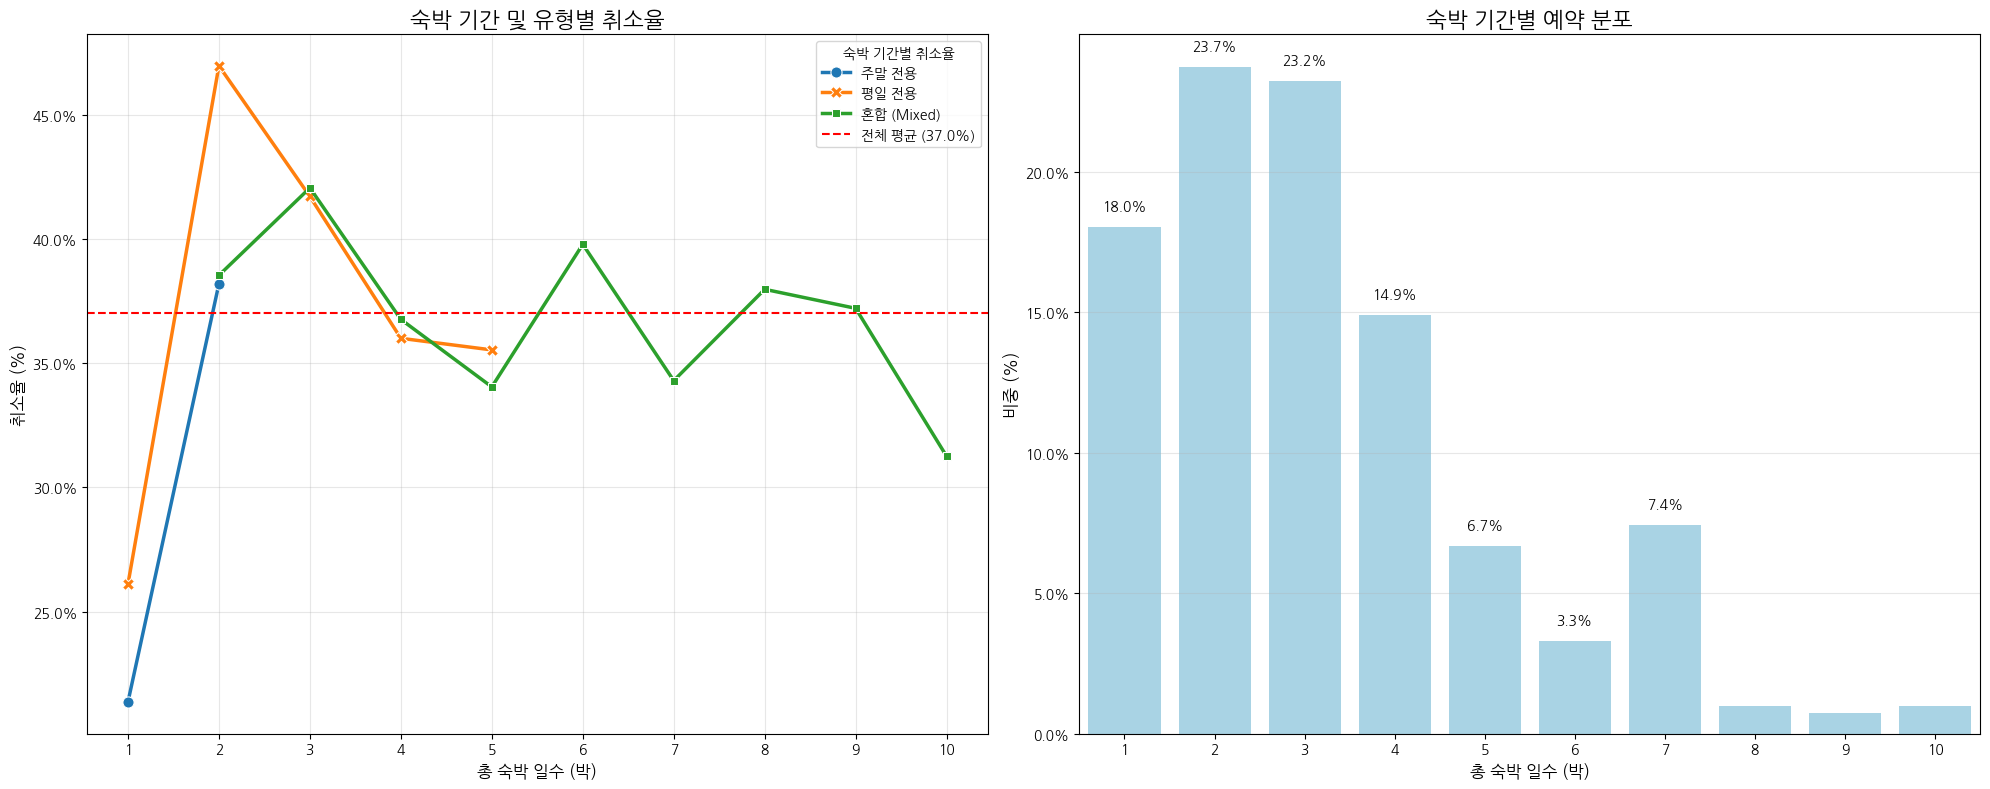

In [46]:
def visualize_stay_duration_combined(df):
    stay_df = df.copy()
    stay_df['total_nights'] = stay_df['stays_in_weekend_nights'] + stay_df['stays_in_week_nights']

    # 10박까지 분석 범위 설정
    stay_df = stay_df[(stay_df['total_nights'] > 0) & (stay_df['total_nights'] <= 10)]

    def classify_stay_type(row):
        weekend = row['stays_in_weekend_nights']
        week = row['stays_in_week_nights']
        if weekend > 0 and week == 0: return '주말 전용'
        elif weekend == 0 and week > 0: return '평일 전용'
        else: return '혼합 (Mixed)'

    stay_df['stay_type'] = stay_df.apply(classify_stay_type, axis=1)

    # 전체 취소율 평균 (참조선용)
    overall_rate = df['is_canceled'].mean()

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # -----
    # 숙박 유형 및 기간에 따른 취소율 그래프
    ax1 = axes[0]

    line_stats = stay_df.groupby(['total_nights', 'stay_type'])['is_canceled'].mean().reset_index()

    sns.lineplot(data=line_stats, x='total_nights', y='is_canceled',
                 hue='stay_type', style='stay_type', markers=True, dashes=False,
                 linewidth=2.5, markersize=8, ax=ax1)

    # 전체 평균선 추가
    ax1.axhline(y=overall_rate, color='red', linestyle='--', linewidth=1.5,
                label=f'전체 평균 ({overall_rate:.1%})')

    ax1.set_title("숙박 기간 및 유형별 취소율", fontsize=16)
    ax1.set_xlabel("총 숙박 일수 (박)", fontsize=12)
    ax1.set_ylabel("취소율 (%)", fontsize=12)
    ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(range(1, 11))
    ax1.legend(title='숙박 기간별 취소율', loc='upper right')

    # -----
    # 숙박 일수별 예약 비중 그래프
    ax2 = axes[1]

    bar_stats = stay_df['total_nights'].value_counts().sort_index().reset_index()
    bar_stats.columns = ['total_nights', 'count']

    total_count = bar_stats['count'].sum()
    bar_stats['percent'] = bar_stats['count'] / total_count

    sns.barplot(data=bar_stats, x='total_nights', y='percent',
                color='skyblue', alpha=0.8, ax=ax2)

    ax2.set_title("숙박 기간별 예약 분포", fontsize=16)
    ax2.set_xlabel("총 숙박 일수 (박)", fontsize=12)
    ax2.set_ylabel("비중 (%)", fontsize=12)
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax2.grid(axis='y', alpha=0.3)

    # 막대 위에 수치 표시 (비중 + 건수)
    for p in ax2.patches:
        height = p.get_height()
        # 너무 작은 비중은 생략
        if height > 0.01:
            ax2.text(p.get_x() + p.get_width()/2., height + 0.005,
                     f'{height:.1%}', ha="center", va="bottom", fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

visualize_stay_duration_combined(df)

- 모든 숙박 유형에서 2 ~ 3박일 때 가장 높은 취소율을 보입니다. 특히 평일 2박 예약은 45%를 넘는 취소율을 보여, 가장 우선적인 리스크 관리가 필요합니다.
- 단기 투숙인 1박은 세번째로 높은 비중과 가장 낮은 취소율을 보입니다. 호텔에 잠시 들렀다 가는 만큼 교통편을 정비하여 접근성을 높이는 전략이 1박 예약 비중을 높이는데 도움이 될 것이라 봅니다.
- 5박, 7박 같은 장기 투숙은 의미있는 예약 비중을 가지면서도 낮은 예약 취소율을 보입니다. 장기 예약 시 혜택을 추가하여 적극적으로 유치를 한다면 큰 취소율 개선을 볼 수 있다고 판단됩니다.

### 3. 출신 국가에 따른 취소율 분석

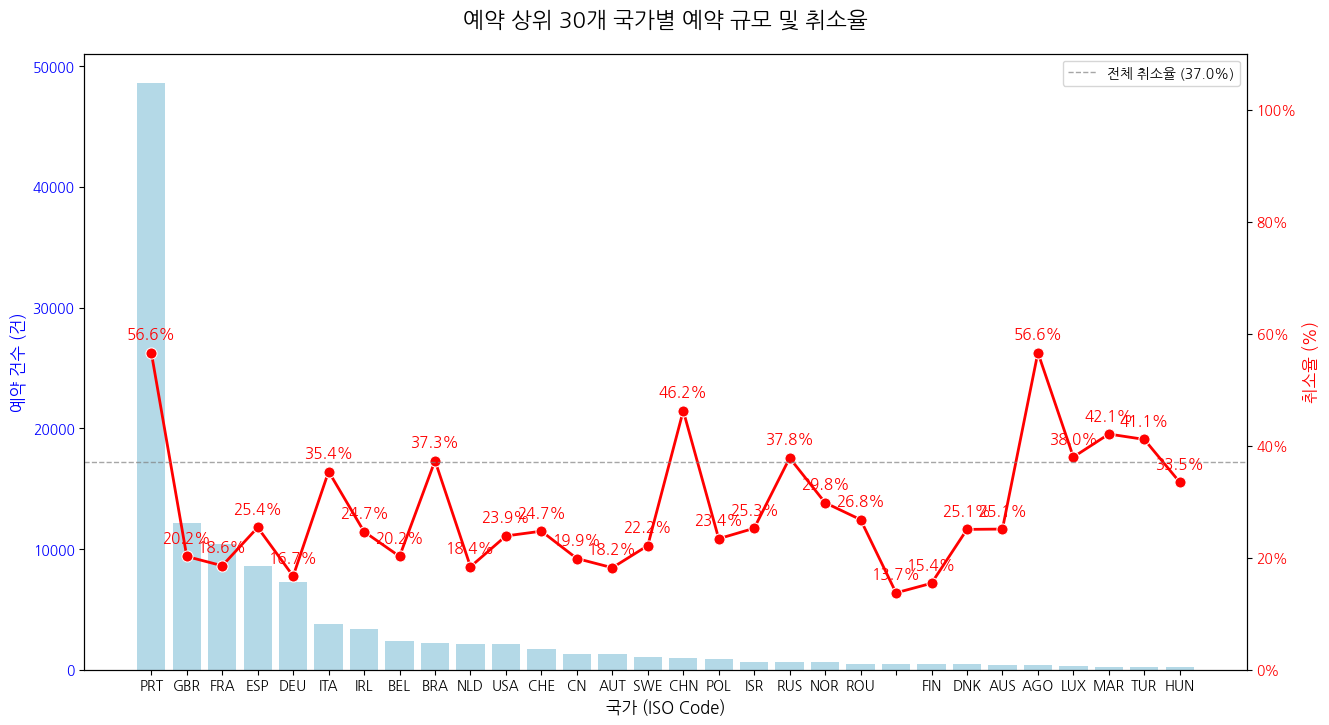

In [50]:
def analyze_country_cancellation(df, top_n=30):
    country_stats = df.groupby('country')['is_canceled'].agg(['count', 'mean']).reset_index()
    country_stats.columns = ['country', 'booking_count', 'cancellation_rate']

    top_countries = country_stats.sort_values(by='booking_count', ascending=False).head(top_n)

    fig, ax1 = plt.subplots(figsize=(15, 8))

    # 왼쪽 축 예약 건수 막대 그래프
    sns.barplot(data=top_countries, x='country', y='booking_count',
                color='skyblue', alpha=0.7, ax=ax1, zorder=1)

    ax1.set_ylabel('예약 건수 (건)', fontsize=12, color='blue')
    ax1.set_xlabel('국가 (ISO Code)', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='blue')

    # 오른쪽 축 취소율 선 그래프
    ax2 = ax1.twinx()

    sns.lineplot(data=top_countries, x='country', y='cancellation_rate',
                 color='red', marker='o', markersize=8, linewidth=2, ax=ax2, zorder=2, sort=False)

    ax2.set_ylabel('취소율 (%)', fontsize=12, color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax2.set_ylim(0, 1.1)

    for i, rate in enumerate(top_countries['cancellation_rate']):
        ax2.text(i, rate + 0.02, f'{rate:.1%}',
                 ha="center", va="bottom", color='red', fontweight='bold', fontsize=11)

    # 전체 평균선 (기준점)
    overall_rate = df['is_canceled'].mean()
    ax2.axhline(y=overall_rate, color='gray', linestyle='--', linewidth=1, alpha=0.7,
                label=f'전체 취소율 ({overall_rate:.1%})')
    ax2.legend(loc='upper right')

    plt.title(f"예약 상위 {top_n}개 국가별 예약 규모 및 취소율", fontsize=16, pad=20)
    plt.grid(axis='x', alpha=0.3)
    plt.show()

# 실행
analyze_country_cancellation(df)

- 데이터의 비중을 보면, 호텔은 포르투갈(PRT) 현지에 있는 것이 확실해 보입니다.
따라서 포르투갈은 현지에서 '부담없는' 예약으로 인해 취소율이 높은 것으로 판단됩니다.  
- 중국(CHN), 앙골라(AGO), 러시아(RUS)는 특별한 사유가 없으면 해외 여행에 필요한 비자 발급이 힘들기 때문에, 호텔 예약을 잡고 비자 발급을 받은 다음에 변심하여 예약을 취소하는 경우가 있다고 합니다. ([참고자료](https://schengenvisareservation.home.blog/2025/10/27/do-embassies-accept-dummy-hotel-bookings-as-valid-proof-of-accommodation-and-how-can-i-get-a-legitimate-one/)) 이런 부분들이 예약 취소에 반영되어 취소율이 높은 것으로 보입니다.
- 이탈리아(ITA)는 트렌드에 민감하게 반응합니다. 여러 여행 조건을 놓고 저울질하다가 이탈하는 경향이 큽니다 ([참고자료 ](https://www.rupp-pr.com/blog/deep-dive-italian-booking-trends))
- 브라질(BRA)은 포르투갈과 언어가 같고, 교류가 활발하기 때문에 현지의 사정 변경에 부담이 없습니다. 따라서 예약이 있더라도 현지 지인과 홍보를 통해 변심할 확률이 높습니다.

따라서, 다음과 같이 국가별 대응이 필요해 보입니다.

- 포르투갈 현지의 예약은 예약 취소와 관련한 패널티를 강조함으로써 '부담없는' 예약 비율을 낮추고, 기념일 할인 등의 유입 요소를 강화하여 유입을 강화하는 전략을 써야 할 것으로 보입니다.
- 중국과 앙골라 등의 비자 발급을 위한 허수 예약을 방지하기 위해서 신용카드 유효성 검사 등이 이루어지는 별도 채널의 운용이 필요해 보입니다.
- 이탈리아, 브라질, 러시아의 예약 취소율을 낮추기 위해서는 혜택 패키지라는 형태의 보증금을 걸고, 그에 따른 '비교우위'를 내세울 수 있는 혜택들이 마케팅 전면에 등장해야 합니다.

### 4. 예약 대기 기간에 따른 취소율 분석

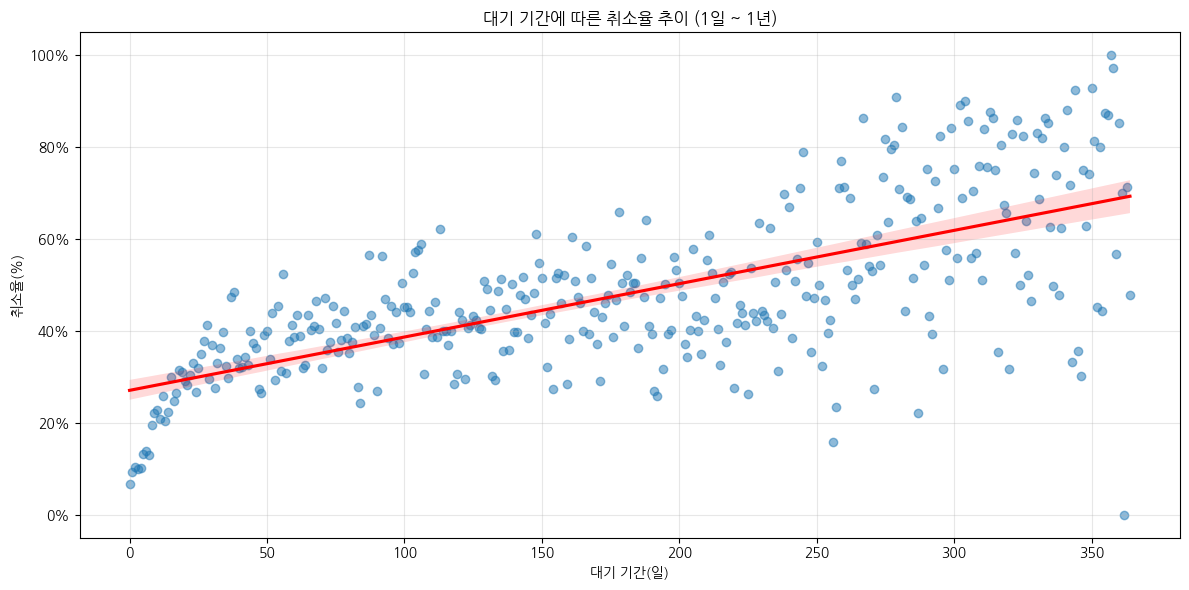

In [43]:
import matplotlib.ticker as mtick

def analyze_cancellation_rate_by_lead_time():
    # lead_time 별로 그룹화하여 취소율(평균) 계산
    lead_time_stats = df.groupby('lead_time')['is_canceled'].mean().reset_index()
    lead_time_stats.columns = ['lead_time', 'cancellation_rate']

    # 노이즈 제거
    lead_time_stats = lead_time_stats[lead_time_stats['lead_time'] < 365]

    plt.figure(figsize=(12, 6))

    sns.regplot(data=lead_time_stats, x='lead_time', y='cancellation_rate',
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.title("대기 기간에 따른 취소율 추이 (1일 ~ 1년)")
    plt.xlabel("대기 기간(일)")
    plt.ylabel("취소율(%)")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

analyze_cancellation_rate_by_lead_time()

- 대기 기간 0 ~ 30일 : 가장 낮은 취소율을 가집니다.
- 대기 기간 30 ~ 150일 : 취소율이 50% 에 근접합니다.
- 대기 기간 150일 이상 : 취소율이 지속적으로 상승하면서 종잡을 수 없는 분포를 보입니다.

즉, **예약 기간이 길어질수록 실제 체크인으로 이어질 확률은 낮아짐**을 확인 할 수 있습니다.

### 5. 예약 방식에 따른 취소율 분석

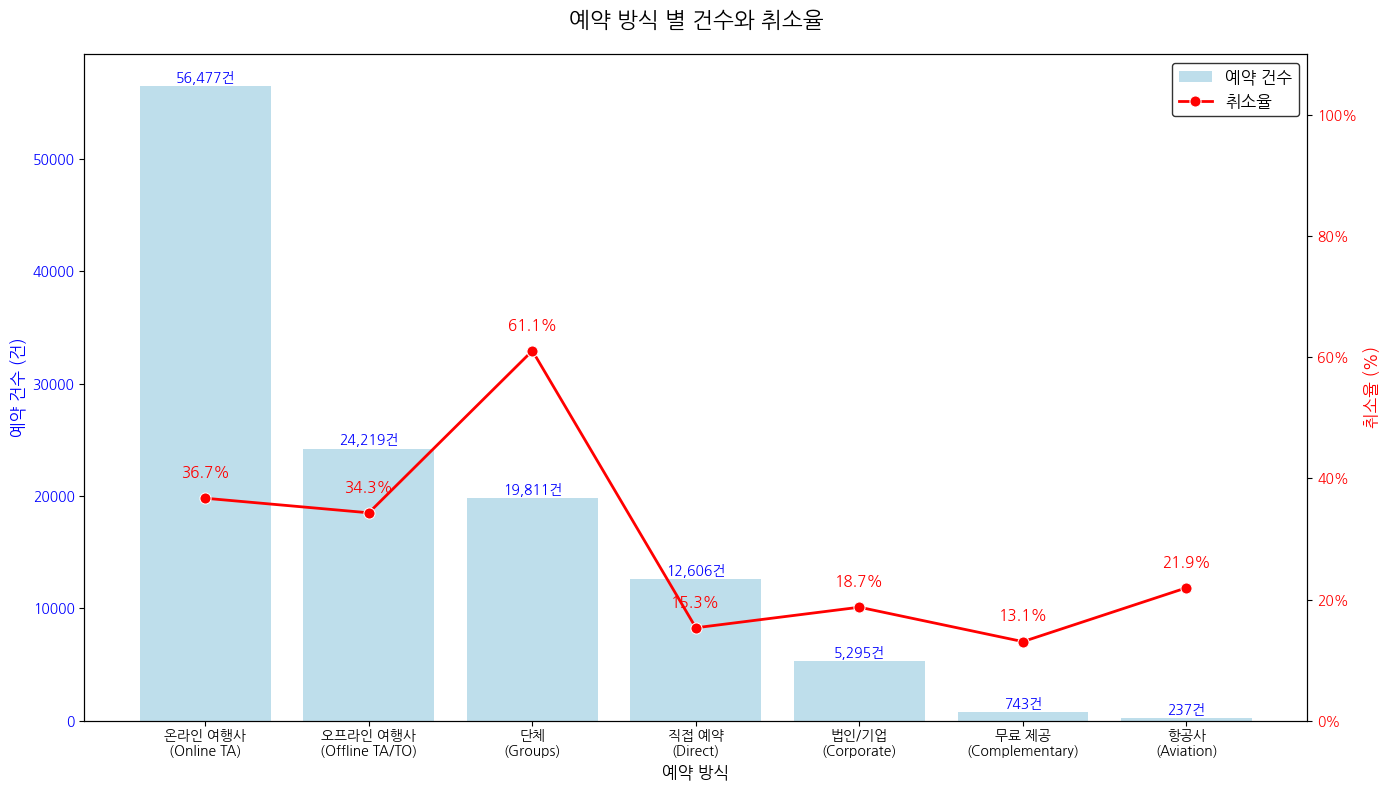

In [22]:
def analyze_cancellation_rate_by_booking_type():
    # agg 함수를 써서 count(건수)와 mean(평균=취소율)을 동시에 구한다.
    combo_df = df.groupby('market_segment')['is_canceled'].agg(['count', 'mean']).reset_index()
    combo_df.columns = ['market_segment', 'booking_count', 'cancellation_rate']

    label_map = {
        'Direct': '직접 예약\n(Direct)', 'Corporate': '법인/기업\n(Corporate)',
        'Online TA': '온라인 여행사\n(Online TA)', 'Offline TA/TO': '오프라인 여행사\n(Offline TA/TO)',
        'Complementary': '무료 제공\n(Complementary)', 'Groups': '단체\n(Groups)',
        'Aviation': '항공사\n(Aviation)', 'Undefined': '미정의\n(Undefined)'
    }
    combo_df['market_segment'] = combo_df['market_segment'].map(label_map)

    # 예약 건수가 많은 순서대로 정렬
    combo_df = combo_df.sort_values(by='booking_count', ascending=False)

    # 노이즈 제거
    combo_df = combo_df[combo_df['market_segment'] != '미정의\n(Undefined)']

    fig, ax1 = plt.subplots(figsize=(14, 8))

    # 왼쪽 막대 그래프 (예약 건수)
    sns.barplot(data=combo_df, x='market_segment', y='booking_count',
                color='skyblue', alpha=0.6, ax=ax1, label='예약 건수')

    ax1.set_ylabel('예약 건수 (건)', fontsize=12, color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_xlabel('예약 방식', fontsize=12)

    # 막대 위에 건수 표시
    for p in ax1.patches:
        height = p.get_height()
        ax1.text(p.get_x() + p.get_width() / 2., height + 100,
                 f'{int(height):,}건', ha="center", va="bottom", color='blue', fontsize=10)

    # 오른쪽 선 그래프 (취소율)
    ax2 = ax1.twinx()  # x축을 공유하는 쌍둥이 y축 생성

    sns.lineplot(data=combo_df, x='market_segment', y='cancellation_rate',
                 color='red', marker='o', markersize=8, linewidth=2, ax=ax2, label='취소율')

    ax2.set_ylabel('취소율 (%)', fontsize=12, color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax2.set_ylim(0, 1.1) # 0~100%가 잘 보이게 1.1배 여유 둠

    # 선 그래프 포인트 위에 % 표시
    for i, rate in enumerate(combo_df['cancellation_rate']):
        ax2.text(i, rate + 0.03, f'{rate:.1%}',
                 ha="center", va="bottom", color='red', fontweight='bold', fontsize=11)

    if ax2.get_legend():
        ax2.get_legend().remove()

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()

    ax1.legend(h1 + h2, l1 + l2, loc='upper right', fontsize=12,
               frameon=True, shadow=False, facecolor='white', edgecolor='black')

    plt.title("예약 방식 별 건수와 취소율", fontsize=16, pad=20)
    plt.grid(True, axis='x', alpha=0.3) # 세로 그리드만 표시해서 가독성 높임

    plt.tight_layout()
    plt.show()

analyze_cancellation_rate_by_booking_type()

온/오프라인 여행사의 취소율이 전체 취소율 37%와 비슷한 수치를 구성하고,  
단체 예약 취소율이 전체 취소율을 더욱 끌어올리는 형태입니다.  
- 온라인 여행사는 약 25000건의 취소가 발생하는 상황인데, 1% 만 개선해도 560건의 예약을 방어할 수 있는 것으로 판단됩니다.
- 오프라인 여행사는 약 8300건의 취소가 발생하고 있습니다. 고객의 변심을 막기위한 조치가 필요하다고 판단됩니다.
- 단체 예약은 예약 시스템 자체에 문제가 있어 보입니다. 약 12000 건의 취소가 발생하고 있습니다. 따라서 가장 시급히 개선해야 된다고 봅니다.
- 직접 예약과 법인 예약은 보다 적극적인 예약 유치가 필요하고 판단됩니다.


## 예약 취소 유형 정리
이제까지 분석한 예약 취소 요인을 조합하여 종합적인 분석을 진행합니다

## 결론